## Data Loading from kaggle-cli

In [89]:
# ! which python

In [90]:
# %pip install kaggle

In [91]:
# # configuring the path of Kaggle.json file
# %mkdir -p ~/.kaggle
# %cp ../kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

In [92]:
# API to fetch the dataset from Kaggle
# ! kaggle datasets download -d mlg-ulb/creditcardfraud -p ~/Desktop/CraditCard_Fraud/Data/

In [93]:
# # extracting the compessed Dataset
# from zipfile import ZipFile
# from pathlib import Path

# zip_path = Path.home() / "Desktop/CraditCard_Fraud/Data/creditcardfraud.zip" # zip file stored
# extract_dir = Path.home() / "Desktop/CraditCard_Fraud/Data/" # .csv file needs to be extracted here

# with ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_dir)

# print("Dataset extracted to:", extract_dir)

## Data analysis

In [94]:
import pandas as pd

- The dataset contains transactions made by credit cards in September 2013 by European cardholders.
- This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.
- It contains only numerical input variables which are the result of a PCA transformation. Unfortunately, due to confidentiality issues, we cannot provide the original features and more background information about the data.
- Features V1, V2, … V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are 'Time' and 'Amount'.
- Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset.
- Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.
- Given the class imbalance ratio, we recommend measuring the accuracy using the Area Under the Precision-Recall Curve (AUPRC). Confusion matrix accuracy is not meaningful for unbalanced classification.

In [95]:
dataset = pd.read_csv('../Data/creditcard.csv')
dataset.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [96]:
dataset.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [97]:
dataset.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [98]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [99]:
# distribution of legit transaction and fraudulent transaction
dataset.groupby('Class').size() # computes each group size size(Class == 0) and size(Class == 1)

Class
0    284315
1       492
dtype: int64

In [100]:
dataset.groupby('Class').count() # counts all the not null values in each columns

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,284315,284315,284315,284315,284315,284315,284315,284315,284315,284315,...,284315,284315,284315,284315,284315,284315,284315,284315,284315,284315
1,492,492,492,492,492,492,492,492,492,492,...,492,492,492,492,492,492,492,492,492,492


In [101]:
dataset['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

## Data preprocessing

In [102]:
# due to heighly imbalanec class values we need to seperate them for amalysis
legit = dataset[dataset.Class == 0]
fraud = dataset[dataset.Class == 1]

In [103]:
print(legit.shape)
print(fraud.shape)

(284315, 31)
(492, 31)


In [104]:
legit_sample = legit.sample(n=20000,random_state=42)
fraud_sample = fraud

dataset_small = pd.concat([legit_sample,fraud_sample])

In [105]:
# statistical measure of the data
dataset_small.Amount.describe()
# precentile measures are also present
# ex. 25%ile of the transaction amount <= $5.65
#     50%ile of the transaction amount <= $22.00

count    20492.000000
mean        87.204299
std        218.972909
min          0.000000
25%          5.000000
50%         21.500000
75%         77.267500
max       6511.000000
Name: Amount, dtype: float64

In [106]:
dataset.Amount.describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

In [107]:
dataset.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


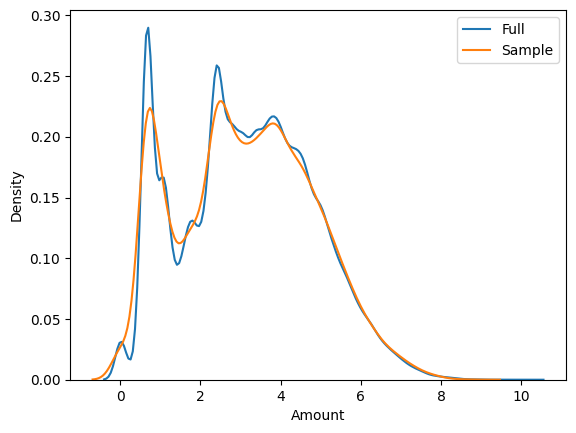

In [108]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

sns.kdeplot(np.log1p(dataset['Amount']), label="Full", bw_adjust=1)
sns.kdeplot(np.log1p(dataset_small['Amount']), label="Sample", bw_adjust=1)

plt.legend()

## Splitting the dataset and train-test split

In [109]:
X = dataset.drop(columns='Class')
Y = dataset['Class']

In [110]:
X.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


In [111]:
Y

0         0
1         0
2         0
3         0
4         0
         ..
284802    0
284803    0
284804    0
284805    0
284806    0
Name: Class, Length: 284807, dtype: int64

In [112]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,
                                                 test_size=0.2,
                                                 stratify=Y,
                                                 random_state=22)

In [113]:
print(X_train.shape,X_test.shape)
print(Y_train.shape,Y_test.shape)

(227845, 30) (56962, 30)
(227845,) (56962,)


In [114]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[['Amount','Time']] = scaler.fit_transform(X_train[['Amount','Time']])
X_test[['Amount','Time']] = scaler.transform(X_test[['Amount','Time']])

In [115]:
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler, ClusterCentroids, TomekLinks
from imblearn.combine import SMOTETomek

In [116]:
samplers = {
    "None": None,
    "RandomOverSampler": RandomOverSampler(random_state=42),
    "RandomUnderSampler": RandomUnderSampler(random_state=42),
    "ClusterCentroids": ClusterCentroids(random_state=42),
    "TomekLinks": TomekLinks(),
    "SMOTE": SMOTE(random_state=42),
    "SMOTETomek": SMOTETomek(random_state=42)
}

## Model Training

In [117]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [118]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric="logloss")
}

In [119]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model"):

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)

    # Train/Test Accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_pred)

    # Probabilities for AUC (if available)
    try:
        y_prob = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    except:
        auc = None

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # Metrics dictionary
    metrics = {
        "confusion_matrix": cm,
        "auc": auc,
        "accuracy": accuracy_score(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred, digits=4),
    }

    print(f"\n{model_name}")
    print(f"Train Accuracy : {train_acc:.4f}")
    print(f"Test Accuracy  : {test_acc:.4f}")

    if auc is not None:
        print(f"AUC Score      : {auc:.4f}")

    print("\nConfusion Matrix")
    print(metrics["confusion_matrix"])

    print("\nClassification Report")
    print(metrics["classification_report"])

    print("-" * 60)

    return metrics

## Evaluation

In [ ]:
results = {}

for sampler_name,sampler in samplers.items():
    if sampler is None:
        X_res, y_res = X_train, Y_train
    else:
        X_res, y_res = sampler.fit_resample(X_train, Y_train)

    for model_name, model in models.items():
        key = f"{sampler_name} + {model_name}"

        results[key] = evaluate_model(
            model,
            X_res,
            y_res,
            X_test,
            Y_test,
            key
        )


None + Logistic Regression
Train Accuracy : 0.9993
Test Accuracy  : 0.9992
AUC Score      : 0.9874

Confusion Matrix
[[56851    13]
 [   33    65]]

Classification Report
              precision    recall  f1-score   support

           0     0.9994    0.9998    0.9996     56864
           1     0.8333    0.6633    0.7386        98

    accuracy                         0.9992     56962
   macro avg     0.9164    0.8315    0.8691     56962
weighted avg     0.9991    0.9992    0.9991     56962

------------------------------------------------------------

None + KNN
Train Accuracy : 0.9996
Test Accuracy  : 0.9996
AUC Score      : 0.9387

Confusion Matrix
[[56857     7]
 [   18    80]]

Classification Report
              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998     56864
           1     0.9195    0.8163    0.8649        98

    accuracy                         0.9996     56962
   macro avg     0.9596    0.9081    0.9323     56962
weighted avg